In [47]:
import random 
from datetime import datetime, timedelta, time
from tqdm import tqdm  # Import tqdm

In [3]:
from SIM.Simulator import dwelling
from SIM.Simulator_Config.config_list_train import (pv_config,
                                                        ev_config,
                                                        thermal_config,
                                                        weather_file,
                                                        demand_config,
                                                        battery_config)
from SIM.Tariff.TariffGenerator import RandomTariffGenerator
from SIM.ControlSignalHandler import ControlSignal

In [25]:
RES = 60
RESOLUTION = timedelta(minutes=RES)  # 1 min resolution info
DURATION = timedelta(days=50)
START_TIME = datetime(2018, 1, 1)

In [40]:
SEED = 0
House = dwelling(name='Dwelling_1',
                 start_time=START_TIME,
                 resolution=RESOLUTION,
                 duration=DURATION,
                 demand_config=demand_config,
                 weather_file=weather_file,
                 pv_config=pv_config,
                 battery_config=battery_config,
                 ev_config=ev_config,
                 thermal_config=thermal_config,
                 seed=SEED)

Simulator: Start time: 2018-01-01 00:00:00: End time:2018-02-20 00:00:00


In [41]:
Tariff_gen = RandomTariffGenerator(low=0.1, high=0.4, resolution=timedelta(minutes=RES), seed=SEED)
House.tariff.tariff_model = Tariff_gen
House.tariff.feed_tariff_model = Tariff_gen
House.tariff.generate_tariff()  # First Generate
House.tariff.updated_tariff()  # Then Update
House.initialized_df()

Simulator: Setup up the demand profile for simulation
Simulator: weather conf detected setting up weather infor (Outdoor Temp C)
epwhandler_V_1_0_3: EPW Data Loaded:
epwhandler_V_1_0_3:   Start datetime: 1982-05-01 01:00:00
epwhandler_V_1_0_3:   End datetime:   1999-09-01 00:00:00
epwhandler_V_1_0_3:   Detected timestep: 0 days 01:00:00
epwhandler_V_1_0_3: ⚠️ Requested start time 2018-01-01 00:00:00 is not an exact EPW timestamp.
epwhandler_V_1_0_3:    Nearest previous: 1999-09-01 00:00:00
epwhandler_V_1_0_3:    Nearest next:     None
epwhandler_V_1_0_3: 📏 Max continuous slot at resolution=0 days 01:00:00: 60 days 23:00:00 (from 1983-09-01 01:00:00 to 1983-11-01 00:00:00)
epwhandler_V_1_0_3: ⚠️ Requested start 2018-01-01 00:00:00 is after EPW end 1999-09-01 00:00:00.
epwhandler_V_1_0_3: 👉 Falling back to EPW start 1982-05-01 01:00:00 and searching from there.
epwhandler_V_1_0_3: ⚠️ Requested start had missing data; found next continuous slot.
epwhandler_V_1_0_3: ✅ Using window start 19

In [42]:
controller = ControlSignal()

In [43]:
current_time = START_TIME
end_time = START_TIME + DURATION
control_signal = {}
start = datetime.now()
day = 0
HVAC_ON = False
# Running a training loop
while current_time <= end_time-RESOLUTION:

    inverter, meter, ev, hvac, status = House.step(control_signal)
    # geting perfect future value

    Demand = House.simulation_df.loc[current_time+RESOLUTION, "Demand Electric Power (kW)"] # next period
    Generation = House.simulation_df.loc[current_time+RESOLUTION, "PV Electric Power (kW)"] # next period

    inverter.forecast_demand = Demand
    inverter.forecast_generation = Generation

    controller.Battery_P_Setpoint = random.randint(-1000, 1000)   # e.g., -3kW (discharge) to 3kW (charge)
    controller.EV_Max_Power = random.randint(0, 3000)            # e.g., 0W to 7kW max EV charging limit
    
    # Generate a random float for temperature setpoint
    if hvac.ti <= 26:
        HVAC_ON = True
    elif hvac.ti >= 18:
        HVAC_ON = False

    if HVAC_ON:
        controller.HVAC_Heating_Power = -8000
    else:
        controller.HVAC_Heating_Power = None

    control_signal = controller.generate_control_signal()
    # print(control_signal)

    current_time += RESOLUTION
    # Update progress bar by 1 step
    
    if current_time.time() == time(12, 00):
        House.tariff.generate_tariff()
    elif current_time.time() == time(0, 0):
        House.tariff.updated_tariff()
        # update the SOC external for training
        next_soc = House.Battery.set_soc(random.uniform(0.05, 1)) # reset that will occur
        day +=1
    # only for RL approch wi
    if (day + 1) % 5 == 0 or day == 1000:
        percent = day / 1000 * 100
        if day == 1000:  # force 100% at the end
            percent = 100
        bar = '█' * int(percent / 5) + '-' * (20 - int(percent / 5))
        print(f"\rSeed {SEED} |{bar}| {percent:.1f}% completed ::Day {day}", end="")

end = datetime.now()
duration = (end - start).total_seconds()


Seed 0 |--------------------| 4.9% completed ::Day 49

In [44]:
House.simulation_df

,Total Electric Power (kW),Total Reactive Power (kVAR),Demand Electric Power (kW),Temperature - Outdoor (C),Global Horizontal Radiation,PV Electric Power (kW),EV Electric Power (kW),EV Set Power (kW),EV SOC (-),EV Parked,Battery Electric Power (kW),Battery Set Power (kW),Battery SOC (-),HVAC Heating Electric Power (kW),HVAC Heating Setpoint (C),Temperature - Indoor (C),User Plug Out Time,Expected SOC
Time,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,-1.252,-1.252,5.118,15.0,636.961687,6.370,0.0,0.0,0.0,0.0,0.000,0.000,1.00000,0.0,0.0,20.80,None,100.0
2018-01-01 01:00:00,14.807,14.807,9.505,14.6,269.786714,2.698,0.0,0.0,0.0,0.0,0.000,0.219,1.00000,8.0,0.0,21.85,None,100.0
2018-01-01 02:00:00,8.782,8.782,1.442,14.1,40.973524,0.410,0.0,0.0,0.0,0.0,-0.250,-0.250,0.95000,8.0,0.0,22.84,None,100.0
2018-01-01 03:00:00,16.344,16.344,9.486,13.6,16.527636,0.165,0.0,0.0,0.0,0.0,-0.977,-0.977,0.75460,8.0,0.0,23.78,None,100.0
2018-01-01 04:00:00,2.706,2.706,3.118,13.1,813.270239,8.133,0.0,0.0,0.0,0.0,-0.279,-0.279,0.69880,8.0,0.0,24.68,None,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-02-19 20:00:00,-4.286,-4.286,4.202,8.7,859.894571,8.599,0.0,0.0,0.0,0.0,0.111,0.111,0.92167,0.0,0.0,25.68,None,100.0
2018-02-19 21:00:00,9.301,9.301,3.737,8.9,177.413471,1.774,0.0,0.0,0.0,0.0,-0.662,-0.662,0.78927,8.0,0.0,26.37,None,100.0
2018-02-19 22:00:00,2.372,2.372,7.065,8.1,480.072269,4.801,0.0,0.0,0.0,0.0,0.108,0.108,0.81087,0.0,0.0,25.77,None,100.0


<Axes: xlabel='Time'>

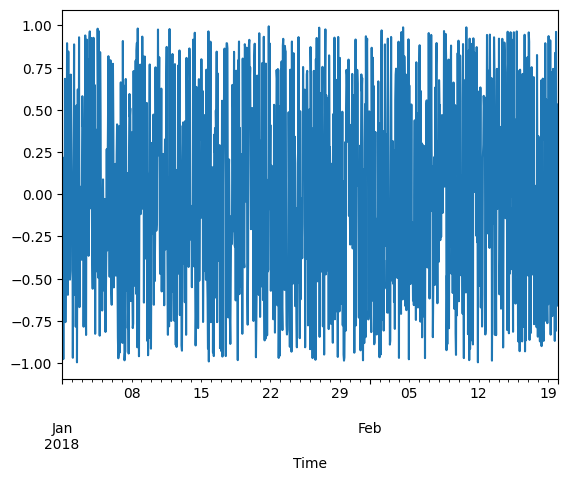

In [45]:
House.simulation_df['Battery Set Power (kW)'].plot()

<Axes: xlabel='Time'>

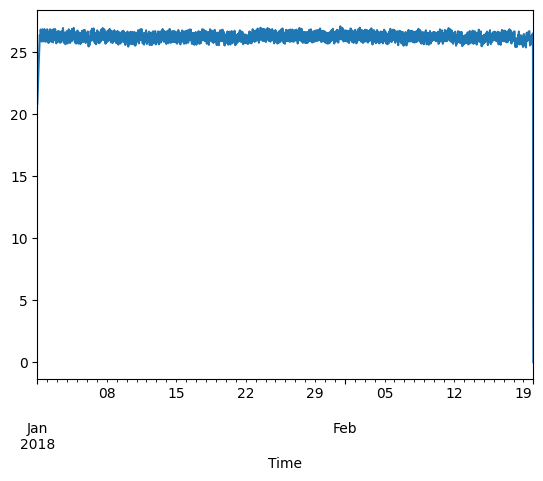

In [46]:
House.simulation_df['Temperature - Indoor (C)'].plot()

<Axes: xlabel='Time'>

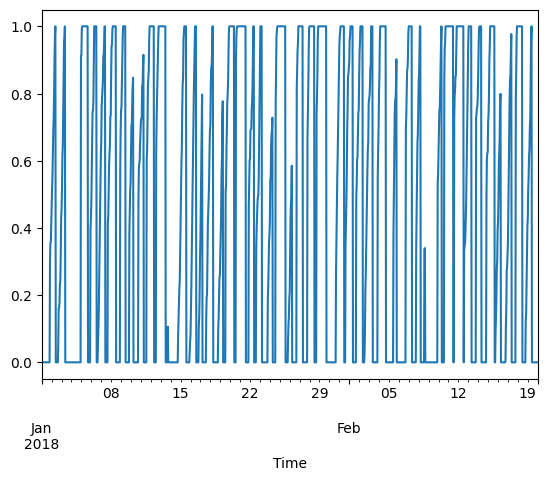

In [48]:
House.simulation_df['EV SOC (-)'].plot()